# Лабораторная 3: Временные ряды (вариант 23)

**ИСУ:** 466703  
**Вариант:** `466703 mod 60 = 23`

В этом ноутбуке:
1. Реализованы 3 метода фильтрации + hard-метод.
2. Выполнено сравнение фильтров на данных `sell.csv` с графиками.
3. Проведен анализ временного ряда (периодичность, автокорреляция, корреляции фич).
4. Сделана hard-секция с двойными датчиками (погода из Open-Meteo).

## Импорты и конфигурация

In [1]:
import json
import urllib.request
import urllib.parse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
DATA_PATH = ROOT / "sell.csv"
OUT_DIR = ROOT / "out_variant23"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANT = 23
FEATURES = ["мыло", "порошок", "средство", "краска", "пена", "прибыль"]

print("ROOT:", ROOT)
print("DATA:", DATA_PATH)
print("OUT:", OUT_DIR)
print("VARIANT:", VARIANT)

ROOT: /Users/vitamija/Desktop/VITA-TOWER/study_project/lab3
DATA: /Users/vitamija/Desktop/VITA-TOWER/study_project/lab3/sell.csv
OUT: /Users/vitamija/Desktop/VITA-TOWER/study_project/lab3/out_variant23
VARIANT: 23


## Загрузка исходной таблицы `sell.csv`

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep=";", encoding="cp1251", header=[0, 1, 2])
print("Raw shape:", df_raw.shape)
df_raw.head(2)

Raw shape: (50, 361)


,Unnamed: 0_level_0,Вариант 1,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Вариант 2,Unnamed: 8_level_0,Unnamed: 9_level_0,...,Unnamed: 351_level_0,Unnamed: 352_level_0,Unnamed: 353_level_0,Unnamed: 354_level_0,Вариант 60,Unnamed: 356_level_0,Unnamed: 357_level_0,Unnamed: 358_level_0,Unnamed: 359_level_0,Unnamed: 360_level_0
,Дни продаж,мыло,порошок,средство,краска,пена,прибыль,мыло,порошок,средство,...,средство,краска,пена,прибыль,мыло,порошок,средство,краска,пена,прибыль
,Unnamed: 0_level_2,шт.,шт.,шт.,шт.,шт.,тыс. руб.,шт.,шт.,шт.,...,шт.,шт.,шт.,тыс. руб.,шт.,шт.,шт.,шт.,шт.,тыс. руб.
0,1,87,25,22,42,22,"26,867",119,17,22,...,18,43,19,"26,926",103,26,18,41,21,"28,787"
1,2,101,14,20,41,20,"28,413",82,19,20,...,25,43,22,"29,674",90,27,21,42,18,"26,369"


## Вспомогательная функция: парсинг чисел с запятой

In [3]:
def parse_ru_number(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).strip().replace(" ", "").replace(",", ".")
    return float(s) if s else np.nan

## Извлечение данных именно для варианта 23

In [ ]:
def extract_variant_frame(df_multi: pd.DataFrame, variant: int) -> pd.DataFrame:
    day_col = ("Unnamed: 0_level_0", "Дни продаж", "Unnamed: 0_level_2")
    days = df_multi[day_col].astype(int)

    block_start = 1 + (variant - 1) * 6
    block = df_multi.iloc[:, block_start : block_start + 6].copy()
    block.columns = FEATURES

    for col in FEATURES:
        block[col] = block[col].map(parse_ru_number)

    out = pd.DataFrame({"day": days})
    for col in FEATURES:
        out[col] = block[col].astype(float)
    return out

df_var = extract_variant_frame(df_raw, VARIANT)
df_var.head()

,day,мыло,порошок,средство,краска,пена,прибыль
0,1,120.0,19.0,17.0,41.0,19.0,27.429
1,2,73.0,21.0,18.0,41.0,23.0,24.801
2,3,77.0,14.0,17.0,41.0,21.0,26.081
3,4,65.0,15.0,21.0,40.0,18.0,23.333
4,5,115.0,12.0,19.0,45.0,22.0,27.892


## Базовый график целевого ряда (прибыль)

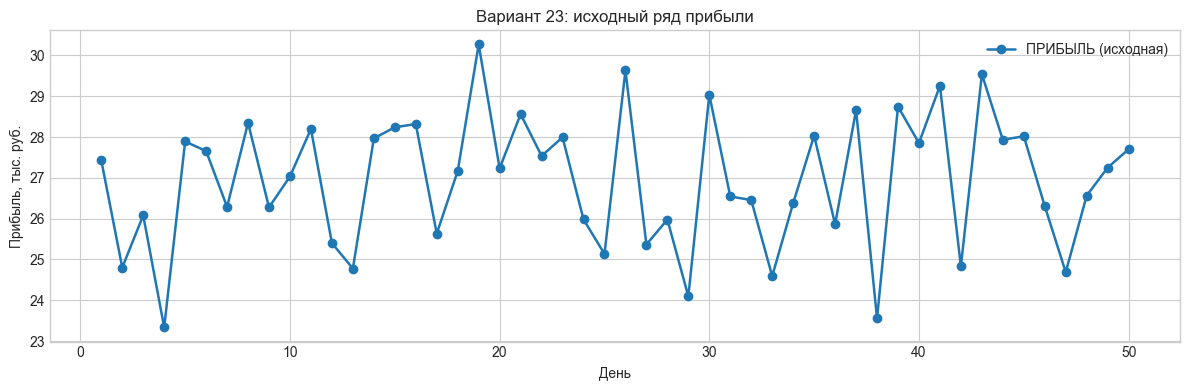

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(df_var["day"], df_var["прибыль"], marker="o", linewidth=1.8, label="ПРИБЫЛЬ (исходная)")
plt.title("Вариант 23: исходный ряд прибыли")
plt.xlabel("День")
plt.ylabel("Прибыль, тыс. руб.")
plt.legend()
plt.tight_layout()
plt.show()

## Фильтр 1: скользящее среднее (SMA)

In [6]:
def sma_filter(x: np.ndarray, window: int = 5) -> np.ndarray:
    window = max(3, int(window))
    if window % 2 == 0:
        window += 1
    pad = window // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(xp, kernel, mode="valid")

## Фильтр 1 (альтернатива): экспоненциальное сглаживание (EMA)

In [7]:
def ema_filter(x: np.ndarray, alpha: float = 0.3) -> np.ndarray:
    alpha = float(alpha)
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

## Фильтр 2: одномерный фильтр Калмана (random walk model)

In [8]:
def kalman_1d(z: np.ndarray, q: float = 0.05, r: float = 0.8) -> np.ndarray:
    x_hat = np.zeros_like(z, dtype=float)
    p = np.zeros_like(z, dtype=float)

    x_hat[0] = z[0]
    p[0] = 1.0

    for k in range(1, len(z)):
        # predict
        x_pred = x_hat[k - 1]
        p_pred = p[k - 1] + q

        # update
        k_gain = p_pred / (p_pred + r)
        x_hat[k] = x_pred + k_gain * (z[k] - x_pred)
        p[k] = (1 - k_gain) * p_pred

    return x_hat

## Фильтр 3: Savitzky–Golay

In [9]:
def savgol_smooth(x: np.ndarray, window: int = 9, polyorder: int = 2) -> np.ndarray:
    if window % 2 == 0:
        window += 1
    window = min(window, len(x) - (1 - len(x) % 2))
    window = max(window, polyorder + 3 if (polyorder + 3) % 2 == 1 else polyorder + 4)
    return savgol_filter(x, window_length=window, polyorder=polyorder, mode="interp")

## Hard-метод: адаптивная LMS-фильтрация

In [10]:
def lms_filter(x: np.ndarray, mu: float = 0.4, order: int = 4, eps: float = 1e-8) -> np.ndarray:
    # Normalized LMS (NLMS) for better numerical stability.
    n = len(x)
    y = np.copy(x).astype(float)
    w = np.zeros(order, dtype=float)

    for i in range(order, n):
        u = x[i - order : i][::-1]
        y_hat = float(np.dot(w, u))
        e = x[i] - y_hat
        norm_u = float(np.dot(u, u)) + eps
        w = w + (mu / norm_u) * e * u
        y[i] = y_hat
    return y

## Применяем фильтры к ряду прибыли

In [11]:
signal = df_var["прибыль"].to_numpy(dtype=float)

filtered = {
    "SMA(5)": sma_filter(signal, window=5),
    "EMA(0.3)": ema_filter(signal, alpha=0.3),
    "Kalman(q=0.05,r=0.8)": kalman_1d(signal, q=0.05, r=0.8),
    "SavGol(9,2)": savgol_smooth(signal, window=9, polyorder=2),
    "LMS(mu=0.4,order=4)": lms_filter(signal, mu=0.4, order=4),
}
list(filtered.keys())

['SMA(5)',
 'EMA(0.3)',
 'Kalman(q=0.05,r=0.8)',
 'SavGol(9,2)',
 'LMS(mu=0.4,order=4)']

## Сравнение качества: добавляем контролируемый шум и считаем метрики

In [12]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true, y_pred, eps=1e-9):
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100)

clean = signal.copy()
noise_std = np.std(clean) * 0.35
noisy = clean + np.random.normal(0, noise_std, size=len(clean))

denoised = {
    "SMA(5)": sma_filter(noisy, window=5),
    "EMA(0.3)": ema_filter(noisy, alpha=0.3),
    "Kalman(q=0.05,r=0.8)": kalman_1d(noisy, q=0.05, r=0.8),
    "SavGol(9,2)": savgol_smooth(noisy, window=9, polyorder=2),
    "LMS(mu=0.4,order=4)": lms_filter(noisy, mu=0.4, order=4),
}

rows = []
for name, yhat in denoised.items():
    rows.append(
        {
            "method": name,
            "RMSE": rmse(clean, yhat),
            "MAE": mae(clean, yhat),
            "MAPE_%": mape(clean, yhat),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
metrics_df

,method,RMSE,MAE,MAPE_%
0,EMA(0.3),1.308690,1.087613,4.062789
1,"Kalman(q=0.05,r=0.8)",1.371131,1.139190,4.242593
2,SMA(5),1.497220,1.230840,4.600716
3,"SavGol(9,2)",1.624968,1.293100,4.840749
4,"LMS(mu=0.4,order=4)",5.227791,2.784028,10.213291


## Графики сравнения фильтров

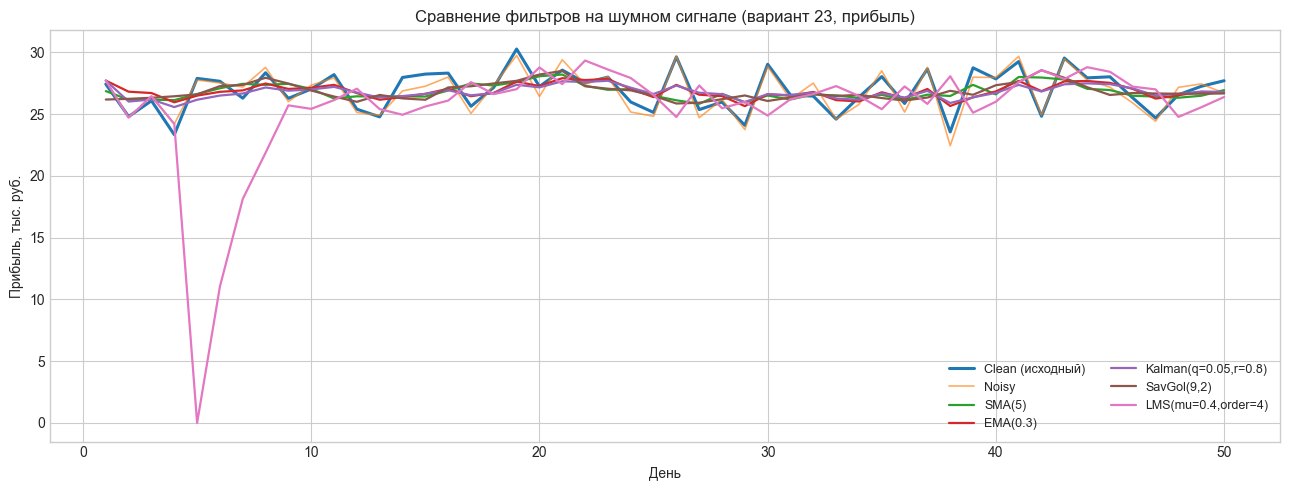

In [13]:
plt.figure(figsize=(13, 5))
plt.plot(df_var["day"], clean, linewidth=2.2, label="Clean (исходный)")
plt.plot(df_var["day"], noisy, linewidth=1.2, alpha=0.65, label="Noisy")
for name, yhat in denoised.items():
    plt.plot(df_var["day"], yhat, linewidth=1.6, label=name)
plt.title("Сравнение фильтров на шумном сигнале (вариант 23, прибыль)")
plt.xlabel("День")
plt.ylabel("Прибыль, тыс. руб.")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Анализ ряда: автокорреляция, периодичность (FFT), корреляции признаков

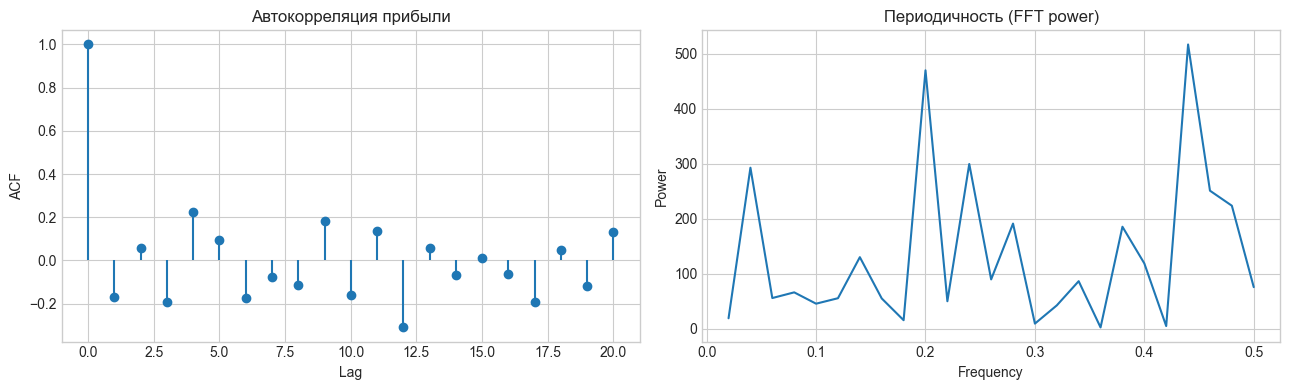

Оценка доминирующего периода (дней): 2.273


,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000000,0.273031,0.455703,-0.144919,0.142491,0.805769
порошок,0.273031,1.000000,0.178767,-0.122396,0.216558,0.179188
средство,0.455703,0.178767,1.000000,-0.197793,0.174890,0.369787
краска,-0.144919,-0.122396,-0.197793,1.000000,0.052381,0.154101
пена,0.142491,0.216558,0.174890,0.052381,1.000000,0.207160
прибыль,0.805769,0.179188,0.369787,0.154101,0.207160,1.000000


In [ ]:
def autocorr(x: np.ndarray, max_lag: int = 20) -> np.ndarray:
    x = x - np.mean(x)
    denom = np.dot(x, x)
    ac = [1.0]
    for lag in range(1, max_lag + 1):
        ac.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.array(ac)

ac = autocorr(signal, max_lag=20)

x_centered = signal - np.mean(signal)
fft_vals = np.fft.rfft(x_centered)
freqs = np.fft.rfftfreq(len(x_centered), d=1.0)
power = np.abs(fft_vals) ** 2
power[0] = 0.0  

peak_idx = int(np.argmax(power))
peak_freq = freqs[peak_idx]
dominant_period = (1.0 / peak_freq) if peak_freq > 0 else np.nan

corr = df_var[["мыло", "порошок", "средство", "краска", "пена", "прибыль"]].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(range(len(ac)), ac, basefmt=" ")
axes[0].set_title("Автокорреляция прибыли")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")

axes[1].plot(freqs[1:], power[1:])
axes[1].set_title("Периодичность (FFT power)")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Power")
plt.tight_layout()
plt.show()

print("Оценка доминирующего периода (дней):", round(dominant_period, 3))
corr

## Hard свобода: двойные датчики (погода для двух городов через Open-Meteo API)

In [ ]:
def fetch_open_meteo_hourly_temp(lat: float, lon: float, start_date: str, end_date: str) -> pd.DataFrame:
    base = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m",
        "timezone": "Europe/Moscow",
    }
    url = f"{base}?{urllib.parse.urlencode(params)}"
    with urllib.request.urlopen(url, timeout=20) as resp:
        payload = json.loads(resp.read().decode("utf-8"))
    return pd.DataFrame(
        {
            "time": payload["hourly"]["time"],
            "temperature": payload["hourly"]["temperature_2m"],
        }
    )

start_date = "2026-04-01"
end_date = "2026-05-10"

try:
    moscow = fetch_open_meteo_hourly_temp(55.7558, 37.6176, start_date, end_date)
    spb = fetch_open_meteo_hourly_temp(59.9343, 30.3351, start_date, end_date)
    dual = moscow.rename(columns={"temperature": "sensor_moscow"}).merge(
        spb.rename(columns={"temperature": "sensor_spb"}), on="time", how="inner"
    )
    dual["time"] = pd.to_datetime(dual["time"])
    dual["mean_temp"] = dual[["sensor_moscow", "sensor_spb"]].mean(axis=1)
    dual["spread"] = dual["sensor_moscow"] - dual["sensor_spb"]
    source_status = "online"
    
except Exception as e:
    n = len(signal)
    t = pd.date_range("2026-04-01", periods=n, freq="D")
    s1 = signal + np.random.normal(0, np.std(signal) * 0.2, size=n)
    s2 = signal + np.random.normal(0, np.std(signal) * 0.25, size=n) + 0.5
    dual = pd.DataFrame({"time": t, "sensor_moscow": s1, "sensor_spb": s2})
    dual["mean_temp"] = dual[["sensor_moscow", "sensor_spb"]].mean(axis=1)
    dual["spread"] = dual["sensor_moscow"] - dual["sensor_spb"]
    source_status = f"fallback:{type(e).__name__}"

dual.head(), source_status

(                 time  sensor_moscow  sensor_spb  mean_temp  spread
 0 2026-04-01 00:00:00            9.4         5.6       7.50     3.8
 1 2026-04-01 01:00:00            8.7         5.3       7.00     3.4
 2 2026-04-01 02:00:00            8.1         4.8       6.45     3.3
 3 2026-04-01 03:00:00            6.9         5.0       5.95     1.9
 4 2026-04-01 04:00:00            6.4         4.8       5.60     1.6,
 'online')

## Фильтрация и выводы по двойным датчикам

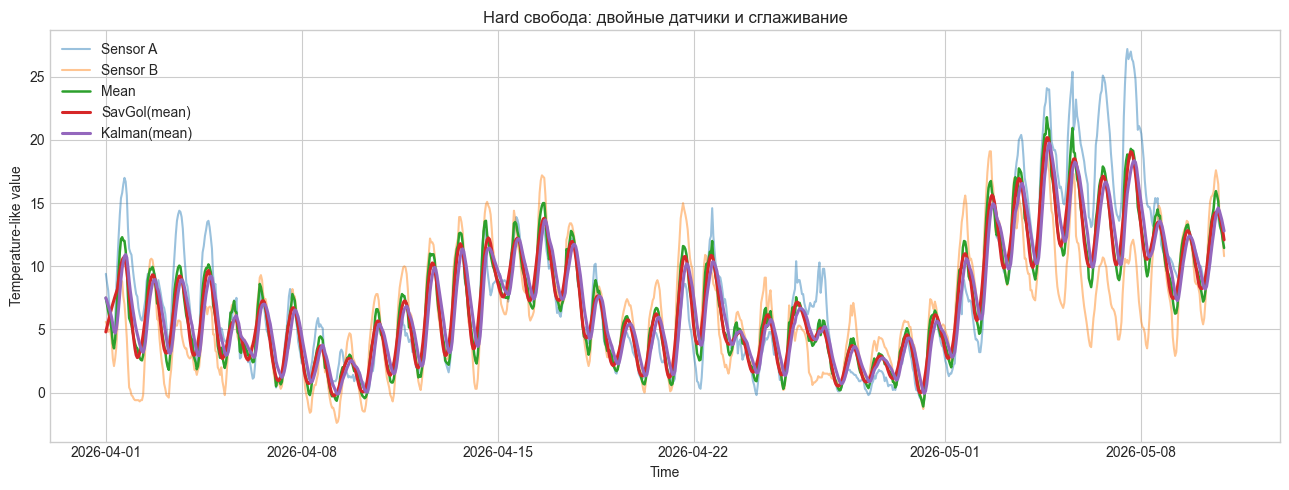

Корреляция между датчиками: 0.6573
Средний сдвиг A-B: 1.2874


In [16]:
dual_mean = dual["mean_temp"].to_numpy(dtype=float)
dual_savgol = savgol_smooth(dual_mean, window=21 if len(dual_mean) >= 21 else 9, polyorder=2)
dual_kalman = kalman_1d(dual_mean, q=0.08, r=0.9)

plt.figure(figsize=(13, 5))
plt.plot(dual["time"], dual["sensor_moscow"], alpha=0.45, label="Sensor A")
plt.plot(dual["time"], dual["sensor_spb"], alpha=0.45, label="Sensor B")
plt.plot(dual["time"], dual_mean, linewidth=1.8, label="Mean")
plt.plot(dual["time"], dual_savgol, linewidth=2.2, label="SavGol(mean)")
plt.plot(dual["time"], dual_kalman, linewidth=2.2, label="Kalman(mean)")
plt.title("Hard свобода: двойные датчики и сглаживание")
plt.xlabel("Time")
plt.ylabel("Temperature-like value")
plt.legend()
plt.tight_layout()
plt.show()

print("Корреляция между датчиками:", round(float(dual[['sensor_moscow', 'sensor_spb']].corr().iloc[0,1]), 4))
print("Средний сдвиг A-B:", round(float(dual['spread'].mean()), 4))

## Сохраняем артефакты (таблицы и метрики)

In [17]:
# Main table for variant 23
variant_path = OUT_DIR / "variant23_series.csv"
df_var.to_csv(variant_path, index=False, encoding="utf-8")

# Metrics table
metrics_path = OUT_DIR / "variant23_filter_metrics.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")

# Dual sensor table
dual_path = OUT_DIR / "hard_dual_sensor.csv"
dual.to_csv(dual_path, index=False, encoding="utf-8")

print("Saved:", variant_path)
print("Saved:", metrics_path)
print("Saved:", dual_path)

Saved: /Users/vitamija/Desktop/VITA-TOWER/study_project/lab3/out_variant23/variant23_series.csv
Saved: /Users/vitamija/Desktop/VITA-TOWER/study_project/lab3/out_variant23/variant23_filter_metrics.csv
Saved: /Users/vitamija/Desktop/VITA-TOWER/study_project/lab3/out_variant23/hard_dual_sensor.csv


## Короткие выводы

In [18]:
best = metrics_df.iloc[0]
print("Лучший метод по RMSE:", best["method"])
print("RMSE:", round(float(best["RMSE"]), 4))
print("MAE:", round(float(best["MAE"]), 4))
print("MAPE%:", round(float(best["MAPE_%"]), 4))

print("\nДоминирующий период ряда прибыли (оценка):", round(float(dominant_period), 3), "дней")
print("Источник hard-данных:", source_status)

Лучший метод по RMSE: EMA(0.3)
RMSE: 1.3087
MAE: 1.0876
MAPE%: 4.0628

Доминирующий период ряда прибыли (оценка): 2.273 дней
Источник hard-данных: online
